In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt



In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)



17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Padding
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)


In [4]:
# Model
model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=32, input_length=200))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [6]:
# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7861 - loss: 0.4200 - val_accuracy: 0.8628 - val_loss: 0.3206
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9548 - loss: 0.1332 - val_accuracy: 0.8348 - val_loss: 0.4093
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9944 - loss: 0.0230 - val_accuracy: 0.8420 - val_loss: 0.5233
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 0.8460 - val_loss: 0.5894
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 0.8436 - val_loss: 0.6312


In [7]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8425 - loss: 0.6208
Accuracy: 0.842519998550415


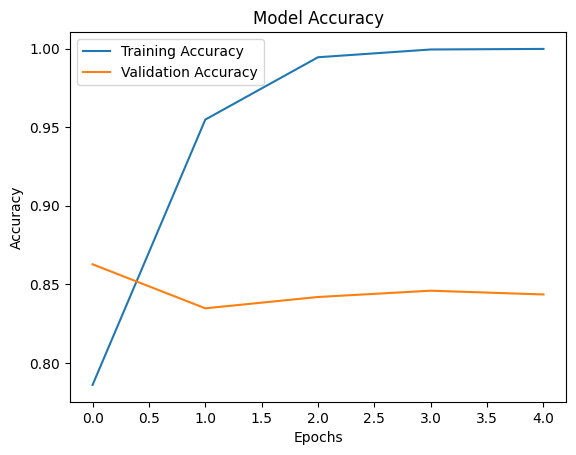

In [8]:
# Simple visual plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()